<h2 style="color:green" align="center">Linear Regression With One Variable using sklearn</h2>

<h4 style="color:purple">Sample problem of predicting home price in Monroe, New Jersey (USA)</h4>

## Dataset
Below table represents current home Prices in ($) in monroe township based on square feet (sqft) Area, New Jersey.

| Area (sqft)    | Price ($)       |
| -------------- | --------------- |
| 2600           | 550000          |
| 3000           | 565000          | 
| 3200           | 610000          | 
| 3600           | 680000          | 
| 4000           | 725000          | 

**Problem Statement**: Given above data build a machine learning model that can predict home prices based on square feet area


You might remember about linear equation from your high school days math class. Home prices can be presented as following equation,

**home price = m * (area) + b**

Generic form of same equation is:

 **y        =  w *  x     + b**

In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import matplotlib.pyplot as plt

In [2]:
# Reading Dataset
df = pd.read_csv('homeprices.csv')
df

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000
5,5000,925000


You can represent values in above table as a scatter plot (values are shown in red markers). After that one can draw a straight line that best fits values on chart. 

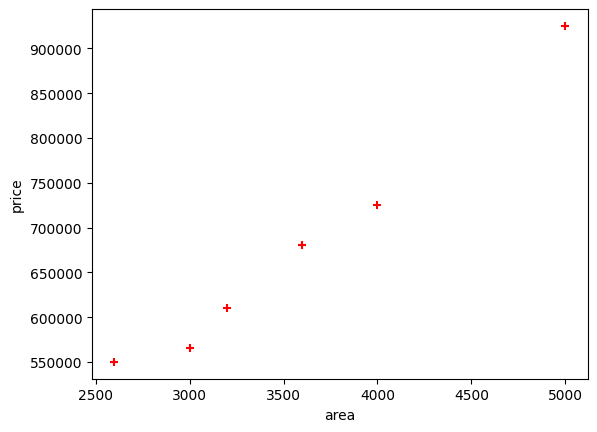

In [3]:
%matplotlib inline
plt.xlabel('area')
plt.ylabel('price')
plt.scatter(df.area,df.price,color='red',marker='+')

In [4]:
# Separating Features from Target variable
new_df = df.drop('price',axis='columns')
new_df

,area
0,2600
1,3000
2,3200
3,3600
4,4000
5,5000


In [5]:
# Separating Target Variable
price = df.price
price

0    550000
1    565000
2    610000
3    680000
4    725000
5    925000
Name: price, dtype: int64

In [6]:
# Initialize linear regression Model 
from sklearn import linear_model

model = linear_model.LinearRegression()

# Training Model
model.fit(new_df, price)

LinearRegression()

**(1) Predict price of a home with area = 3300 sqr ft**

In [7]:
model.predict([[3300]])

C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([632738.53211009])

In [8]:
# Check value of W (weight, coefficient) after training

w = model.coef_
w

array([161.60550459])

In [9]:
# Check value of b (bias, intercept)

b = model.intercept_
b

np.float64(99440.36697247718)

**Y = w * X + b (w is coefficient and b is intercept)**

In [10]:
w * 5000 + b

array([907467.88990826])

**(1) Predict price of a home with area = 5000 sqr ft**

In [11]:
model.predict([[5000]])

C:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([907467.88990826])

<h3 style="color:purple">Generate CSV file with list of home price predictions</h3>

In [12]:
area_df = pd.read_csv("areas.csv")
area_df.head(3)

,area
0,1000
1,1500
2,2300


In [13]:
# Saving predictions in variable p
p = model.predict(area_df)
p

array([ 261045.87155963,  341848.62385321,  471133.02752294,
        671523.85321101,  765255.04587156,  836361.46788991,
        986654.58715596,  658595.41284404,  867066.51376147,
        471133.02752294, 1553889.90825688, 1489247.70642202,
       1246839.44954128])

In [14]:
area_df['prices']=p
area_df

,area,prices
0,1000,2.610459e+05
1,1500,3.418486e+05
2,2300,4.711330e+05
3,3540,6.715239e+05
4,4120,7.652550e+05
5,4560,8.363615e+05
6,5490,9.866546e+05
7,3460,6.585954e+05
8,4750,8.670665e+05
9,2300,4.711330e+05


In [15]:
# Saving Test Predictions into csv file
area_df.to_csv("prediction.csv")